In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120})

DATA_DIR = Path("../data")
if not DATA_DIR.exists():
    DATA_DIR = Path("Durga/Lab/MLDL/data")

pd.set_option("display.max_columns", 120)

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

df = pd.read_csv(DATA_DIR / "naive_bayes_purchase.csv")
for col in df.columns:
    df[col] = df[col].astype(str).str.strip()
display(df.head())
display(df["Purchase"].value_counts().rename_axis("Purchase").reset_index(name="count"))

,Day,Discount,Free Delivery,Purchase
0,Weekday,Yes,Yes,Yes
1,Weekday,Yes,Yes,Yes
2,Weekday,No,No,No
3,Holiday,Yes,Yes,Yes
4,Weekend,Yes,Yes,Yes


,Purchase,count
0,Yes,24
1,No,6


Accuracy: 0.889
              precision    recall  f1-score   support

          No       1.00      0.50      0.67         2
         Yes       0.88      1.00      0.93         7

    accuracy                           0.89         9
   macro avg       0.94      0.75      0.80         9
weighted avg       0.90      0.89      0.87         9



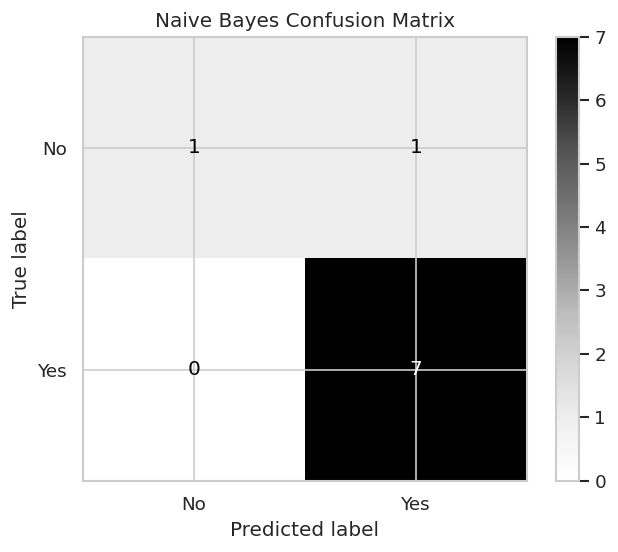

,Day,Discount,Free Delivery,actual,predicted,prob_No,prob_Yes
24,Holiday,No,No,No,No,0.770,0.230
13,Holiday,Yes,Yes,Yes,Yes,0.031,0.969
9,Holiday,Yes,Yes,Yes,Yes,0.031,0.969
22,Holiday,No,Yes,Yes,Yes,0.309,0.691
4,Weekend,Yes,Yes,Yes,Yes,0.013,0.987
8,Weekend,Yes,Yes,Yes,Yes,0.013,0.987
29,Weekend,Yes,Yes,Yes,Yes,0.013,0.987
21,Weekend,Yes,Yes,No,Yes,0.013,0.987
26,Weekday,Yes,Yes,Yes,Yes,0.021,0.979


In [3]:
X = df.drop(columns=["Purchase"])
y = df["Purchase"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

model = Pipeline(
    steps=[
        ("encode", OneHotEncoder(handle_unknown="ignore")),
        ("nb", MultinomialNB(alpha=1.0)),
    ]
)
model.fit(X_train, y_train)
pred = model.predict(X_test)
proba = model.predict_proba(X_test)

print(f"Accuracy: {accuracy_score(y_test, pred):.3f}")
print(classification_report(y_test, pred))
ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap="Greys")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

result = X_test.copy()
result["actual"] = y_test.values
result["predicted"] = pred
for idx, cls in enumerate(model.named_steps["nb"].classes_):
    result[f"prob_{cls}"] = proba[:, idx].round(3)
display(result)

In [4]:
feature_names = model.named_steps["encode"].get_feature_names_out(X.columns)
log_probs = pd.DataFrame(
    model.named_steps["nb"].feature_log_prob_,
    index=model.named_steps["nb"].classes_,
    columns=feature_names,
).T
display(log_probs.sort_values(model.named_steps["nb"].classes_[0], ascending=False))

,No,Yes
Discount_No,-1.335001,-2.451005
Free Delivery_No,-1.558145,-2.674149
Day_Holiday,-1.845827,-2.268684
Day_Weekday,-1.845827,-1.863218
Free Delivery_Yes,-2.251292,-1.352393
Day_Weekend,-2.944439,-2.451005
Discount_Yes,-2.944439,-1.421386
